In [1]:
# Import modules 
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#install psql "driver"
!pip3 install psycopg2-binary

In [3]:
from sqlalchemy import create_engine

In [4]:
#Write your code in one or more cells (please remove this line from your notebook)

engine_string = "postgresql+psycopg2://postgres:postgres123@pg_sql:5432/postgres"
engine = create_engine(engine_string)
retail_df = pd.read_sql_table("retail", engine)
retail_df.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
retail_df.shape

(1067371, 8)

In [6]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   invoice_no    1067371 non-null  object        
 1   stock_code    1067371 non-null  object        
 2   description   1062989 non-null  object        
 3   quantity      1067371 non-null  int64         
 4   invoice_date  1067371 non-null  datetime64[ns]
 5   unit_price    1067371 non-null  float64       
 6   customer_id   824364 non-null   float64       
 7   country       1067371 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 65.1+ MB


In [7]:
raw = retail_df.copy()
base = raw.copy()

In [8]:
pd.options.display.float_format = '{:,.2f}'.format

In [9]:
# invoice_no should be an identifier (string-like)
base["invoice_no"] = base["invoice_no"].astype(str).str.strip()

# stock_code + description normalization
base["stock_code"]  = base["stock_code"].astype(str).str.strip().str.upper()
base["description"] = base["description"].astype(str).str.strip().str.upper()

# parse invoice_date safely
base["invoice_date"] = pd.to_datetime(base["invoice_date"], errors="coerce")

# numeric coercion
base["quantity"]    = pd.to_numeric(base["quantity"], errors="coerce")
base["unit_price"]  = pd.to_numeric(base["unit_price"], errors="coerce")
base["customer_id"] = pd.to_numeric(base["customer_id"], errors="coerce")

# country normalization
base["country"] = base["country"].astype(str).str.strip()


In [10]:
# Core null check (Is any of our rows actually broken)
base[[
    "invoice_no",
    "stock_code",
    "description",
    "invoice_date",
    "quantity",
    "unit_price",
    "customer_id",
    "country"
]].isna().sum().sort_values(ascending=False)

customer_id     243007
country              0
unit_price           0
quantity             0
invoice_date         0
description          0
stock_code           0
invoice_no           0
dtype: int64

In [11]:
base["quantity"].describe()

count   1,067,371.00
mean            9.94
std           172.71
min       -80,995.00
25%             1.00
50%             3.00
75%            10.00
max        80,995.00
Name: quantity, dtype: float64

In [12]:
base["quantity"].value_counts().head(10)

1     294346
2     159960
12    121745
6      85299
3      72638
4      72382
24     47036
10     40956
8      25819
5      23165
Name: quantity, dtype: int64

In [13]:
(base["quantity"] == 0).sum(), (base["quantity"] < 0).sum()

(0, 22950)

In [14]:
base["unit_price"].describe()

count   1,067,371.00
mean            4.65
std           123.55
min       -53,594.36
25%             1.25
50%             2.10
75%             4.15
max        38,970.00
Name: unit_price, dtype: float64

In [15]:
(base["quantity"] == 0).sum(), (base["quantity"] < 0).sum()

(0, 22950)

In [16]:
base["description"].str.upper().value_counts().head(30)

WHITE HANGING HEART T-LIGHT HOLDER    5918
REGENCY CAKESTAND 3 TIER              4412
NAN                                   4382
JUMBO BAG RED RETROSPOT               3469
ASSORTED COLOUR BIRD ORNAMENT         2958
PARTY BUNTING                         2765
STRAWBERRY CERAMIC TRINKET BOX        2613
LUNCH BAG  BLACK SKULL.               2529
JUMBO STORAGE BAG SUKI                2434
HEART OF WICKER SMALL                 2319
JUMBO SHOPPER VINTAGE RED PAISLEY     2297
60 TEATIME FAIRY CAKE CASES           2271
PAPER CHAIN KIT 50'S CHRISTMAS        2215
LUNCH BAG SPACEBOY DESIGN             2206
REX CASH+CARRY JUMBO SHOPPER          2199
HOME BUILDING BLOCK WORD              2192
WOODEN FRAME ANTIQUE WHITE            2189
LUNCH BAG CARS BLUE                   2184
NATURAL SLATE HEART CHALKBOARD        2151
BAKING SET 9 PIECE RETROSPOT          2150
WOODEN PICTURE FRAME WHITE FINISH     2115
POSTAGE                               2115
HEART OF WICKER LARGE                 2112
PACK OF 60 

In [17]:
base["description"].str.contains(
    "POSTAGE|SHIPPING|DELIVERY|DISCOUNT|ADJUST|FEE|CARRIAGE|MANUAL|NAN",
    case=False,
    na=False
).value_counts()

False    1049265
True       18106
Name: description, dtype: int64

In [18]:
# 2) Diagnostics-backed rules (based on previous results)
# Core required fields for *any* transaction line
core_cols = ["invoice_no","stock_code","description","invoice_date","quantity","unit_price"]
base["has_core_fields"] = base[core_cols].notna().all(axis=1)

# Cancel / reversal signals
base["is_cancelled_invoice"] = base["invoice_no"].str.startswith("C")
base["is_qty_reversal"]      = base["quantity"] < 0
base["is_price_reversal"]    = base["unit_price"] < 0

# Description validity (NAN' exists as a literal)
base["has_valid_description"] = (
    base["description"].notna() &
    (~base["description"].isin(["NAN", "NA", "N/A", "UNKNOWN", "UNSPECIFIED", ""]))
    & (base["description"].str.len() >= 3)
)

# Non-product lines (you proved POSTAGE exists)
NON_PRODUCT_KEYWORDS = [
    "POSTAGE","SHIPPING","DELIVERY","DISCOUNT","ADJUST","ADJUSTMENT",
    "FEE","CARRIAGE","MANUAL","CHARGE","BANK","ROUNDING"
]
pattern = "|".join(NON_PRODUCT_KEYWORDS)
base["is_non_product_line"] = base["description"].str.contains(pattern, na=False)

# Price/Qty sanity (you proved 0 quantity doesn't exist; keep checks anyway)
base["is_zero_qty"]   = base["quantity"] == 0
base["is_zero_price"] = base["unit_price"] == 0

# Economics
base["net_revenue"]   = base["quantity"] * base["unit_price"]
base["gross_revenue"] = base["quantity"].abs() * base["unit_price"].abs()

#Duplicates
dup_cols = ["invoice_no","stock_code","quantity","unit_price","invoice_date"]
base["is_duplicate_line"] = base.duplicated(subset=dup_cols, keep="first")

base["has_customer_id"] = base["customer_id"].notna()


In [19]:
base.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,has_core_fields,is_cancelled_invoice,is_qty_reversal,is_price_reversal,has_valid_description,is_non_product_line,is_zero_qty,is_zero_price,net_revenue,gross_revenue,is_duplicate_line,has_customer_id
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,True,False,False,False,True,False,False,False,83.40,83.40,False,True
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,True,False,False,False,True,False,False,False,81.00,81.00,False,True
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,True,False,False,False,True,False,False,False,81.00,81.00,False,True
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,True,False,False,False,True,False,False,False,100.80,100.80,False,True
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,True,False,False,False,True,False,False,False,30.00,30.00,False,True


In [20]:
# --- OUTLIER ISOLATION (ECONOMIC, EXEC-SAFE) ---

# 1) Compute line-level net revenue (if not already)
base["net_revenue"] = base["quantity"] * base["unit_price"]

# 2) Invoice-level net revenue (captures "one huge order" problem)
invoice_net = base.groupby("invoice_no")["net_revenue"].sum()

# 3) Define an "extreme" threshold using percentiles (business framing: top 0.1%)
INV_PCTL = 0.999
inv_cap = invoice_net.quantile(INV_PCTL)

# 4) Flag outlier invoices
base["is_invoice_outlier"] = base["invoice_no"].isin(invoice_net[invoice_net > inv_cap].index)

# 5) Unit price outliers (captures "crazy unit price" problem)
PRICE_PCTL = 0.999
price_cap = base["unit_price"].quantile(PRICE_PCTL)

base["is_price_outlier"] = base["unit_price"] > price_cap

# 6) Quantity outliers (captures "crazy quantity" problem)
QTY_PCTL = 0.999
qty_cap = base["quantity"].abs().quantile(QTY_PCTL)

base["is_qty_outlier"] = base["quantity"].abs() > qty_cap

# 7) One combined flag (easy to use in KPI views)
base["is_economic_outlier"] = (
    base["is_invoice_outlier"] |
    base["is_price_outlier"]  |
    base["is_qty_outlier"]
)


In [21]:
base.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,has_core_fields,is_cancelled_invoice,...,is_zero_qty,is_zero_price,net_revenue,gross_revenue,is_duplicate_line,has_customer_id,is_invoice_outlier,is_price_outlier,is_qty_outlier,is_economic_outlier
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,True,False,...,False,False,83.40,83.40,False,True,False,False,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,True,False,...,False,False,81.00,81.00,False,True,False,False,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,True,False,...,False,False,81.00,81.00,False,True,False,False,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,True,False,...,False,False,100.80,100.80,False,True,False,False,False,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,True,False,...,False,False,30.00,30.00,False,True,False,False,False,False


In [22]:
base["business_value_bucket"] = np.select(
    [
        # 1) Unusable rows (cannot support any business insight)
        (~base["has_core_fields"]) |
        (~base["has_valid_description"]) |
        (base["invoice_date"].isna()),

        # 2) Operational / non-product charges
        base["is_non_product_line"],

        # 3) Risk / reversal rows (leakage signal)
        (
            base["is_cancelled_invoice"] |
            base["is_qty_reversal"] |
            base["is_price_reversal"] |
            (base["net_revenue"] < 0)
        ),

        # 4) Clean realized revenue rows
        (
            (~base["is_non_product_line"]) &
            (~base["is_cancelled_invoice"]) &
            (base["quantity"] > 0) &
            (base["unit_price"] > 0) &
            (~base["is_duplicate_line"]) &
            (~base["is_invoice_outlier"]) &
            (~base["is_price_outlier"])
        )
    ],
    [
        "UNUSABLE_RECORD",
        "OPERATIONAL_CHARGE",
        "RISK_REVERSAL",
        "REVENUE_SALE"
    ],
    default="OTHER_REVIEW"
)


In [23]:
base["business_value_bucket"].value_counts()

REVENUE_SALE          986140
OTHER_REVIEW           41563
RISK_REVERSAL          18728
OPERATIONAL_CHARGE     16459
UNUSABLE_RECORD         4481
Name: business_value_bucket, dtype: int64

In [24]:
df_total_revenue = base[
    # valid product sale
    (base["has_core_fields"]) &
    (base["has_valid_description"]) &
    (~base["is_non_product_line"]) &
    (~base["is_cancelled_invoice"]) &
    (base["quantity"] > 0) &
    (base["unit_price"] > 0)
].copy()

df_risk    = base[base["business_value_bucket"] == "RISK_REVERSAL"].copy()

In [25]:
df_customer = df_total_revenue[df_total_revenue["has_customer_id"]].copy()
df_customer["customer_id"] = df_customer["customer_id"].astype(int)

In [26]:
# KPI 1: Total Revenue (realized revenue baseline)
kpi_total_revenue = df_total_revenue["net_revenue"].sum()
kpi_total_revenue

19895263.236999996

In [27]:
df_structural = df_total_revenue[~df_total_revenue["is_economic_outlier"]].copy()

In [28]:
# KPI 2: Monthly Revenue Trend

monthly_revenue = (
    df_structural
    .assign(month=df_structural["invoice_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month", as_index=False)
    .agg(monthly_revenue=("net_revenue", "sum"))
    .sort_values("month")
)

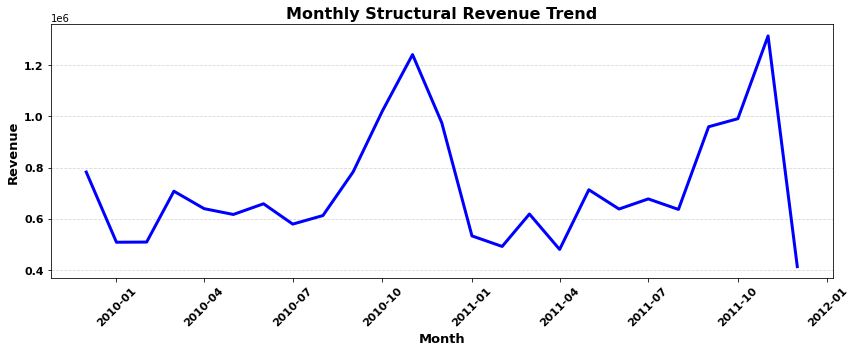

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["monthly_revenue"],
    linewidth=3,
    color="blue"
)

plt.title(
    "Monthly Structural Revenue Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Month",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Revenue",
    fontsize=13,
    fontweight="bold"
)

# Bold X-axis ticks
plt.xticks(
    rotation=45,
    fontsize=11,
    fontweight="bold"
)

# Bold Y-axis ticks
plt.yticks(
    fontsize=11,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

In [30]:
# KPI 3: AOV 
# Order-level revenue (INCLUDING outliers)
order_revenue = (
    df_total_revenue
    .groupby("invoice_no", as_index=False)
    .agg(order_revenue=("net_revenue", "sum"))
)

# Average Order Value
kpi_aov = order_revenue["order_revenue"].mean()
kpi_aov

503.7795816114668

In [31]:
# Active customers = distinct identified customers with at least one valid product transaction
kpi_active_customers = (
    df_total_revenue
    .loc[df_total_revenue["has_customer_id"], "customer_id"]
    .nunique()
)

kpi_active_customers

5851

In [32]:
#KPI 5: Revenue per identified customer (INCLUDING outliers)
customer_revenue = (
    df_total_revenue
    .loc[df_total_revenue["has_customer_id"]]
    .groupby("customer_id", as_index=False)
    .agg(customer_revenue=("net_revenue", "sum"))
)

# Average revenue per customer
kpi_revenue_per_customer = customer_revenue["customer_revenue"].mean()
kpi_revenue_per_customer

2948.8342004785463

In [33]:
#KPI 6: Revenue per customer (STRUCTURAL revenue only - No outliers here coz - can skew results)
customer_revenue_structural = (
    df_structural
    .loc[df_structural["has_customer_id"]]
    .groupby("customer_id", as_index=False)
    .agg(revenue=("net_revenue", "sum"))
)

# Sort customers by revenue contribution
customer_revenue_structural = customer_revenue_structural.sort_values(
    "revenue", ascending=False
).reset_index(drop=True)

# Top 10% customers
top_pct = 0.10
top_n = int(np.ceil(top_pct * len(customer_revenue_structural)))

# Revenue share of top 10%
kpi_top10pct_customer_share = (
    customer_revenue_structural.head(top_n)["revenue"].sum()
    / customer_revenue_structural["revenue"].sum()
)

kpi_top10pct_customer_share

0.6131086816144768

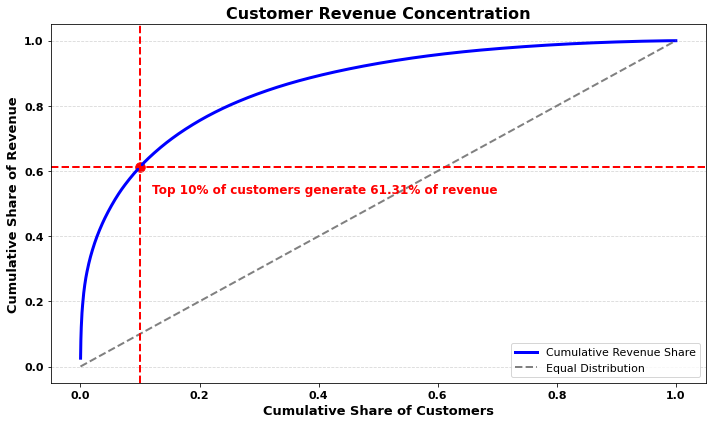

In [34]:
cr = customer_revenue_structural.copy()

# Cumulative % of customers (x-axis) and cumulative % of revenue (y-axis)
cr["customer_rank_pct"] = (np.arange(len(cr)) + 1) / len(cr)
cr["cumulative_revenue_pct"] = cr["revenue"].cumsum() / cr["revenue"].sum()

# Fixed executive reference point
x_10 = 0.10
y_10 = 0.6131  # 61.31%

plt.figure(figsize=(10, 6))

# Cumulative revenue curve
plt.plot(
    cr["customer_rank_pct"],
    cr["cumulative_revenue_pct"],
    linewidth=3,
    color="blue",
    label="Cumulative Revenue Share"
)

# Equality line
plt.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=2,
    color="gray",
    label="Equal Distribution"
)

# Vertical line at top 10% customers
plt.axvline(
    x=x_10,
    linestyle="--",
    linewidth=2,
    color="red"
)

# Horizontal line at 61.31% revenue
plt.axhline(
    y=y_10,
    linestyle="--",
    linewidth=2,
    color="red"
)

# Highlight intersection point
plt.scatter(x_10, y_10, color="red", s=90)

# Annotation
plt.text(
    x_10 + 0.02,
    y_10 - 0.08,
    "Top 10% of customers generate 61.31% of revenue",
    fontsize=12,
    fontweight="bold",
    color="red"
)

plt.title(
    "Customer Revenue Concentration",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Cumulative Share of Customers",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Cumulative Share of Revenue",
    fontsize=13,
    fontweight="bold"
)

plt.xticks(fontsize=11, fontweight="bold")
plt.yticks(fontsize=11, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()


In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# KPI 7: RFM Profile of Top 10% Revenue Customers (STRUCTURAL)
# -----------------------------

# 1) Build RFM base table on df_structural (consistent with KPI 6)
analysis_date = df_structural["invoice_date"].max() + pd.Timedelta(days=1)

rfm = (
    df_structural
    .loc[df_structural["has_customer_id"]]
    .dropna(subset=["customer_id"])
    .assign(customer_id=lambda df: df["customer_id"].astype(int))
    .groupby("customer_id", as_index=False)
    .agg(
        monetary=("net_revenue", "sum"),
        frequency=("invoice_no", "nunique"),
        last_purchase=("invoice_date", "max")
    )
)

rfm["recency"] = (analysis_date - rfm["last_purchase"]).dt.days


# 2) Create RFM scores using quartiles (same logic as your earlier notebook)
# Recency: lower is better, so we label quartiles as [4,3,2,1] (most recent gets 4)
rfm["R"] = pd.qcut(rfm["recency"], 4, labels=[4, 3, 2, 1]).astype(int)

# Frequency & Monetary: higher is better; rank() helps avoid duplicate-bin issues
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)

rfm["RFM_score"] = rfm["R"] + rfm["F"] + rfm["M"]


# 3) Map RFM score to executive-friendly segments (same as your earlier notebook)
def rfm_segment(score):
    if score >= 10:
        return "High-Value Loyal"
    elif score >= 8:
        return "Frequent / Potential Loyal"
    elif score >= 6:
        return "New / Low Engagement"
    else:
        return "At-Risk / Dormant"

rfm["segment"] = rfm["RFM_score"].apply(rfm_segment)


# 4) Identify KPI 6 Top 10% customers by structural revenue
customer_revenue_structural = (
    df_structural
    .loc[df_structural["has_customer_id"]]
    .groupby("customer_id", as_index=False)
    .agg(revenue=("net_revenue", "sum"))
    .assign(customer_id=lambda df: df["customer_id"].astype(int))
    .sort_values("revenue", ascending=False)
    .reset_index(drop=True)
)

top_pct = 0.10
top_n = int(np.ceil(top_pct * len(customer_revenue_structural)))

top_customers = set(customer_revenue_structural.head(top_n)["customer_id"])
rfm["is_top10pct_customer"] = rfm["customer_id"].isin(top_customers)


# 5) Focus analysis only on Top 10% customers
rfm_top = rfm.loc[rfm["is_top10pct_customer"]].copy()

# Summary table for Top 10% group
rfm_top_summary = (
    rfm_top
    .groupby("segment", as_index=False)
    .agg(
        top_customers=("customer_id", "nunique"),
        top_revenue=("monetary", "sum")
    )
)

# Add shares within the top group
rfm_top_summary["customer_share_within_top10pct"] = (
    rfm_top_summary["top_customers"] / rfm_top_summary["top_customers"].sum()
)
rfm_top_summary["revenue_share_within_top10pct"] = (
    rfm_top_summary["top_revenue"] / rfm_top_summary["top_revenue"].sum()
)

# Add contribution to total revenue (optional but powerful for execs)
total_structural_revenue = customer_revenue_structural["revenue"].sum()
rfm_top_summary["share_of_total_revenue"] = rfm_top_summary["top_revenue"] / total_structural_revenue

# Order segments (nice for storytelling)
segment_order = ["High-Value Loyal", "Frequent / Potential Loyal", "New / Low Engagement", "At-Risk / Dormant"]
rfm_top_summary["segment"] = pd.Categorical(rfm_top_summary["segment"], categories=segment_order, ordered=True)
rfm_top_summary = rfm_top_summary.sort_values("segment").reset_index(drop=True)

rfm_top_summary

,segment,top_customers,top_revenue,customer_share_within_top10pct,revenue_share_within_top10pct,share_of_total_revenue
0,High-Value Loyal,560,"9,469,341.13",0.96,0.97,0.60
1,Frequent / Potential Loyal,22,"228,468.33",0.04,0.02,0.01
2,New / Low Engagement,3,"23,633.90",0.01,0.00,0.00


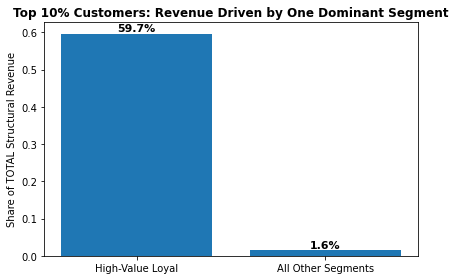

In [43]:
# Prepare data
data = rfm_top_summary.copy()

# Identify dominant segment
hero_row = data.loc[data["share_of_total_revenue"].idxmax()]
hero_name = hero_row["segment"]
hero_value = hero_row["share_of_total_revenue"]

others_value = data["share_of_total_revenue"].sum() - hero_value

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    [hero_name, "All Other Segments"],
    [hero_value, others_value]
)

ax.set_ylabel("Share of TOTAL Structural Revenue")
ax.set_title(
    "Top 10% Customers: Revenue Driven by One Dominant Segment",
    weight="bold"
)

for i, v in enumerate([hero_value, others_value]):
    ax.text(i, v, f"{v:.1%}", ha="center", va="bottom", fontsize=11, weight="bold")

plt.tight_layout()
plt.show()


In [44]:
# KPI 9: Top Products by Structural Revenue

top_products = (
    df_structural
    .dropna(subset=["description"])
    .assign(product=lambda df: df["description"].str.strip().str.upper())
    .groupby("product", as_index=False)
    .agg(
        revenue=("net_revenue", "sum"),
        transactions=("invoice_no", "nunique")
    )
    .sort_values("revenue", ascending=False)
)

# Take Top 10 products
top_10_products = top_products.head(10).copy()

# Revenue share
total_revenue = top_products["revenue"].sum()
top_10_products["revenue_share"] = top_10_products["revenue"] / total_revenue

top_10_products

,product,revenue,transactions,revenue_share
3721,REGENCY CAKESTAND 3 TIER,"326,768.07",3895,0.02
5040,WHITE HANGING HEART T-LIGHT HOLDER,"236,497.83",5432,0.01
3119,PARTY BUNTING,"146,835.21",2665,0.01
2356,JUMBO BAG RED RETROSPOT,"141,075.48",3251,0.01
266,ASSORTED COLOUR BIRD ORNAMENT,"113,960.56",2795,0.01
3088,PAPER CHAIN KIT 50'S CHRISTMAS,"93,384.25",2000,0.01
961,CHILLI LIGHTS,"83,199.97",1130,0.00
2361,JUMBO BAG STRAWBERRY,"66,604.06",1846,0.00
475,BLACK RECORD COVER FRAME,"66,029.35",631,0.00
2370,JUMBO STORAGE BAG SUKI,"59,683.03",2318,0.00


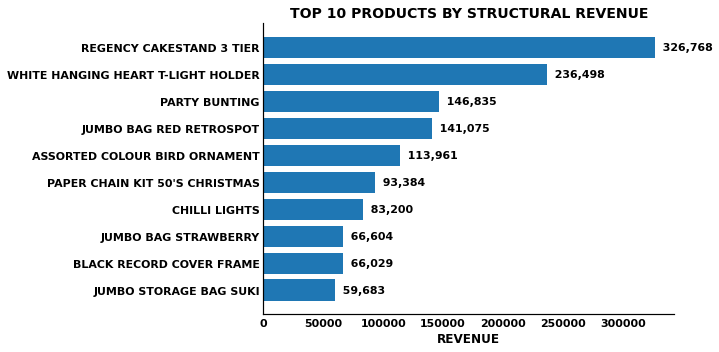

In [59]:
fig, ax = plt.subplots(figsize=(10, 5))

# Horizontal bar chart
ax.barh(
    top_10_products["product"][::-1],
    top_10_products["revenue"][::-1]
)

# Titles & labels (ALL BOLD)
ax.set_title(
    "TOP 10 PRODUCTS BY STRUCTURAL REVENUE",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel(
    "REVENUE",
    fontsize=12,
    fontweight="bold"
)
ax.set_ylabel("")

# --- Spine control ---
# Keep only left (Y) and bottom (X) axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

# Make remaining axes slightly thicker (optional but nice)
ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# Remove tick marks but keep labels
ax.tick_params(axis="x", length=0, labelsize=11)
ax.tick_params(axis="y", length=0, labelsize=11)

# Make tick labels bold
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# Value labels on bars (BOLD)
for i, v in enumerate(top_10_products["revenue"][::-1]):
    ax.text(
        v,
        i,
        f"  {v:,.0f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [60]:
# KPI 10: Top Products by Volume (Units Sold)

top_products_units = (
    df_structural
    .dropna(subset=["description"])
    .assign(product=lambda df: df["description"].str.strip().str.upper())
    .groupby("product", as_index=False)
    .agg(
        units=("quantity", "sum"),
        revenue=("net_revenue", "sum")
    )
    .sort_values("units", ascending=False)
)

top_10_products_units = top_products_units.head(10).copy()
top_10_products_units

,product,units,revenue
5040,WHITE HANGING HEART T-LIGHT HOLDER,85909,"236,497.83"
2356,JUMBO BAG RED RETROSPOT,74133,"141,075.48"
266,ASSORTED COLOUR BIRD ORNAMENT,69409,"113,960.56"
5160,WORLD WAR 2 GLIDERS ASSTD DESIGNS,68784,"17,261.04"
124,60 TEATIME FAIRY CAKE CASES,50368,"25,603.11"
3032,PACK OF 60 PINK PAISLEY CAKE CASES,49357,"25,326.61"
3034,PACK OF 72 RETRO SPOT CAKE CASES,43657,"22,681.48"
3035,PACK OF 72 RETROSPOT CAKE CASES,40698,"24,464.27"
278,ASSORTED COLOURS SILK FAN,40014,"30,054.22"
4608,STRAWBERRY CERAMIC TRINKET BOX,37329,"47,753.77"


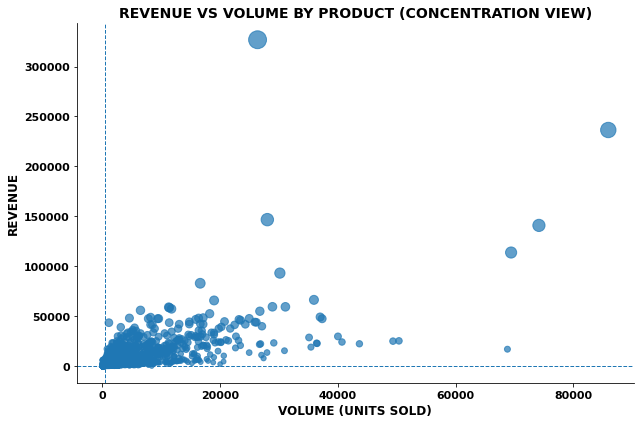

In [62]:
# KPI 10: Revenue vs Volume Concentration (Product Mix Risk)

product_mix = (
    df_structural
    .dropna(subset=["description"])
    .assign(product=lambda df: df["description"].str.strip().str.upper())
    .groupby("product", as_index=False)
    .agg(
        revenue=("net_revenue", "sum"),
        volume=("quantity", "sum")
    )
)

# Median reference lines
median_revenue = product_mix["revenue"].median()
median_volume = product_mix["volume"].median()

# Scatter plot
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    product_mix["volume"],
    product_mix["revenue"],
    s=(product_mix["revenue"] / product_mix["revenue"].max()) * 300 + 20,
    alpha=0.7
)

# Median lines
ax.axhline(median_revenue, linestyle="--", linewidth=1)
ax.axvline(median_volume, linestyle="--", linewidth=1)

# Titles & labels (bold)
ax.set_title(
    "REVENUE VS VOLUME BY PRODUCT (CONCENTRATION VIEW)",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel(
    "VOLUME (UNITS SOLD)",
    fontsize=12,
    fontweight="bold"
)
ax.set_ylabel(
    "REVENUE",
    fontsize=12,
    fontweight="bold"
)

# Keep only X & Y axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=11)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()
plt.show()

In [68]:
geo_revenue_structural = (
    df_structural
    .dropna(subset=["country"])
    .groupby("country", as_index=False)
    .agg(revenue=("net_revenue", "sum"))
    .sort_values("revenue", ascending=False)
    .reset_index(drop=True)
)

geo_revenue_structural["revenue_share"] = (
    geo_revenue_structural["revenue"] / geo_revenue_structural["revenue"].sum()
)

top_geo_structural = geo_revenue_structural.head(10).copy()
top_geo_structural

,country,revenue,revenue_share
0,United Kingdom,"15,607,060.86",0.86
1,EIRE,"543,127.63",0.03
2,Netherlands,"428,065.17",0.02
3,Germany,"383,502.51",0.02
4,France,"300,202.21",0.02
5,Spain,"98,115.15",0.01
6,Switzerland,"93,476.73",0.01
7,Sweden,"81,246.74",0.00
8,Australia,"71,302.05",0.00
9,Belgium,"56,343.27",0.00


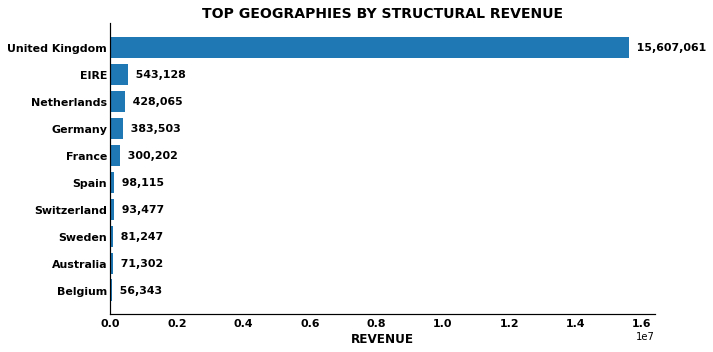

In [69]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    top_geo["country"][::-1],
    top_geo["revenue"][::-1]
)

ax.set_title(
    "TOP GEOGRAPHIES BY STRUCTURAL REVENUE",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel(
    "REVENUE",
    fontsize=12,
    fontweight="bold"
)
ax.set_ylabel("")

# Keep only X & Y axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(True)
ax.spines["bottom"].set_visible(True)

ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

ax.tick_params(axis="x", length=0, labelsize=11)
ax.tick_params(axis="y", length=0, labelsize=11)

for label in ax.get_xticklabels():
    label.set_fontweight("bold")
for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# Value labels
for i, v in enumerate(top_geo["revenue"][::-1]):
    ax.text(
        v,
        i,
        f"  {v:,.0f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()